In [1]:
#load required libraries
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import liana as li
from liana.method import cellphonedb

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

#load data
print("Reading data...")
adata = sc.read_h5ad("../Data/Annotated.h5ad")

# Store the counts for later use
adata.layers["counts"] = adata.X.copy()

Reading data...


In [2]:
sc.pp.filter_cells(adata, min_genes=4000)
sc.pp.filter_genes(adata, min_cells=100)

filtered out 67096 cells that have less than 4000 genes expressed
filtered out 6161 genes that are detected in less than 100 cells


In [3]:
adata

AnnData object with n_obs × n_vars = 25846 × 17088
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'percent.mt', 'percent.hbb', 'percent.hba', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'n_genes'
    var: 'total_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'n_cells'
    uns: 'neighbors', 'over_clustering', 'predicted_labels_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [4]:
# log1p normalize the data
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:01)


In [5]:
adata

AnnData object with n_obs × n_vars = 25846 × 17088
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'percent.mt', 'percent.hbb', 'percent.hba', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'n_genes'
    var: 'total_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'n_cells'
    uns: 'neighbors', 'over_clustering', 'predicted_labels_colors', 'umap', 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [6]:
adata.obs["predicted_labels"].cat.categories

Index(['B cells', 'Basophils', 'Cholangiocytes', 'Endothelial cells',
       'Fibroblasts', 'Hepatocytes', 'ILC1s', 'Kupffer cells', 'Mig. cDCs',
       'Monocytes & Monocyte-derived cells', 'NK cells', 'Neutrophils',
       'T cells', 'cDC1s', 'cDC2s', 'pDCs'],
      dtype='object')

In [7]:
bdata = adata
bdata.raw = bdata

In [8]:
unique_mice = bdata.obs['orig.ident'].unique()

In [9]:
mouse_data = bdata[bdata.obs['orig.ident'] == 'SPF_HF_118']
    
# Run CellPhoneDB on the filtered data
cellphonedb(mouse_data,
             groupby='predicted_labels',
             resource_name='mouseconsensus',
             expr_prop=0.1,
             verbose=True, key_added='cpdb_res')

Using `.raw`!
Converting mat to CSR format


/s/medinfo/bmi776/miniconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


8 features of mat are empty, they will be removed.


/s/medinfo/bmi776/miniconda3/lib/python3.12/site-packages/pandas/core/indexing.py:1857: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/gupta385/.local/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


The following cell identities were excluded: Hepatocytes
0.30 of entities in the resource are missing from the data.
Generating ligand-receptor stats for 5024 samples and 17080 features


100%|██████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:14<00:00, 66.68it/s]
/home/gupta385/.local/lib/python3.12/site-packages/liana/method/_Method.py:265: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [10]:
mouse_data.uns['cpdb_res']

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
98512,App,App,1.250792,1.000000,Cd74,Cd74,1.869475,1.000000,Neutrophils,cDC1s,1.560133,0.000
95297,App,App,1.227161,1.000000,Cd74,Cd74,1.869475,1.000000,Endothelial cells,cDC1s,1.548318,0.000
105309,App,App,1.250792,1.000000,Cd74,Cd74,1.836114,1.000000,Neutrophils,cDC2s,1.543453,0.000
101717,App,App,1.227161,1.000000,Cd74,Cd74,1.836114,1.000000,Endothelial cells,cDC2s,1.531638,0.000
79205,Spp1,Spp1,1.725233,1.000000,Cd44,Cd44,1.315134,1.000000,Cholangiocytes,Neutrophils,1.520183,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
39531,L1cam,L1cam,0.054907,0.103825,Erbb2,Erbb2,0.049800,0.111111,pDCs,Fibroblasts,0.052354,0.629
27377,Vwf,Vwf,0.052991,0.100346,Itga2b,Itga2b_Itgb3,0.049581,0.103920,Monocytes & Monocyte-derived cells,Endothelial cells,0.051286,0.954
32985,Btc,Btc,0.052638,0.111111,Erbb2,Egfr_Erbb2,0.049800,0.111111,Fibroblasts,Fibroblasts,0.051219,0.327
25138,Icam4,Icam4,0.051315,0.111111,Itga2b,Itga2b,0.049581,0.103920,Fibroblasts,Endothelial cells,0.050448,0.000


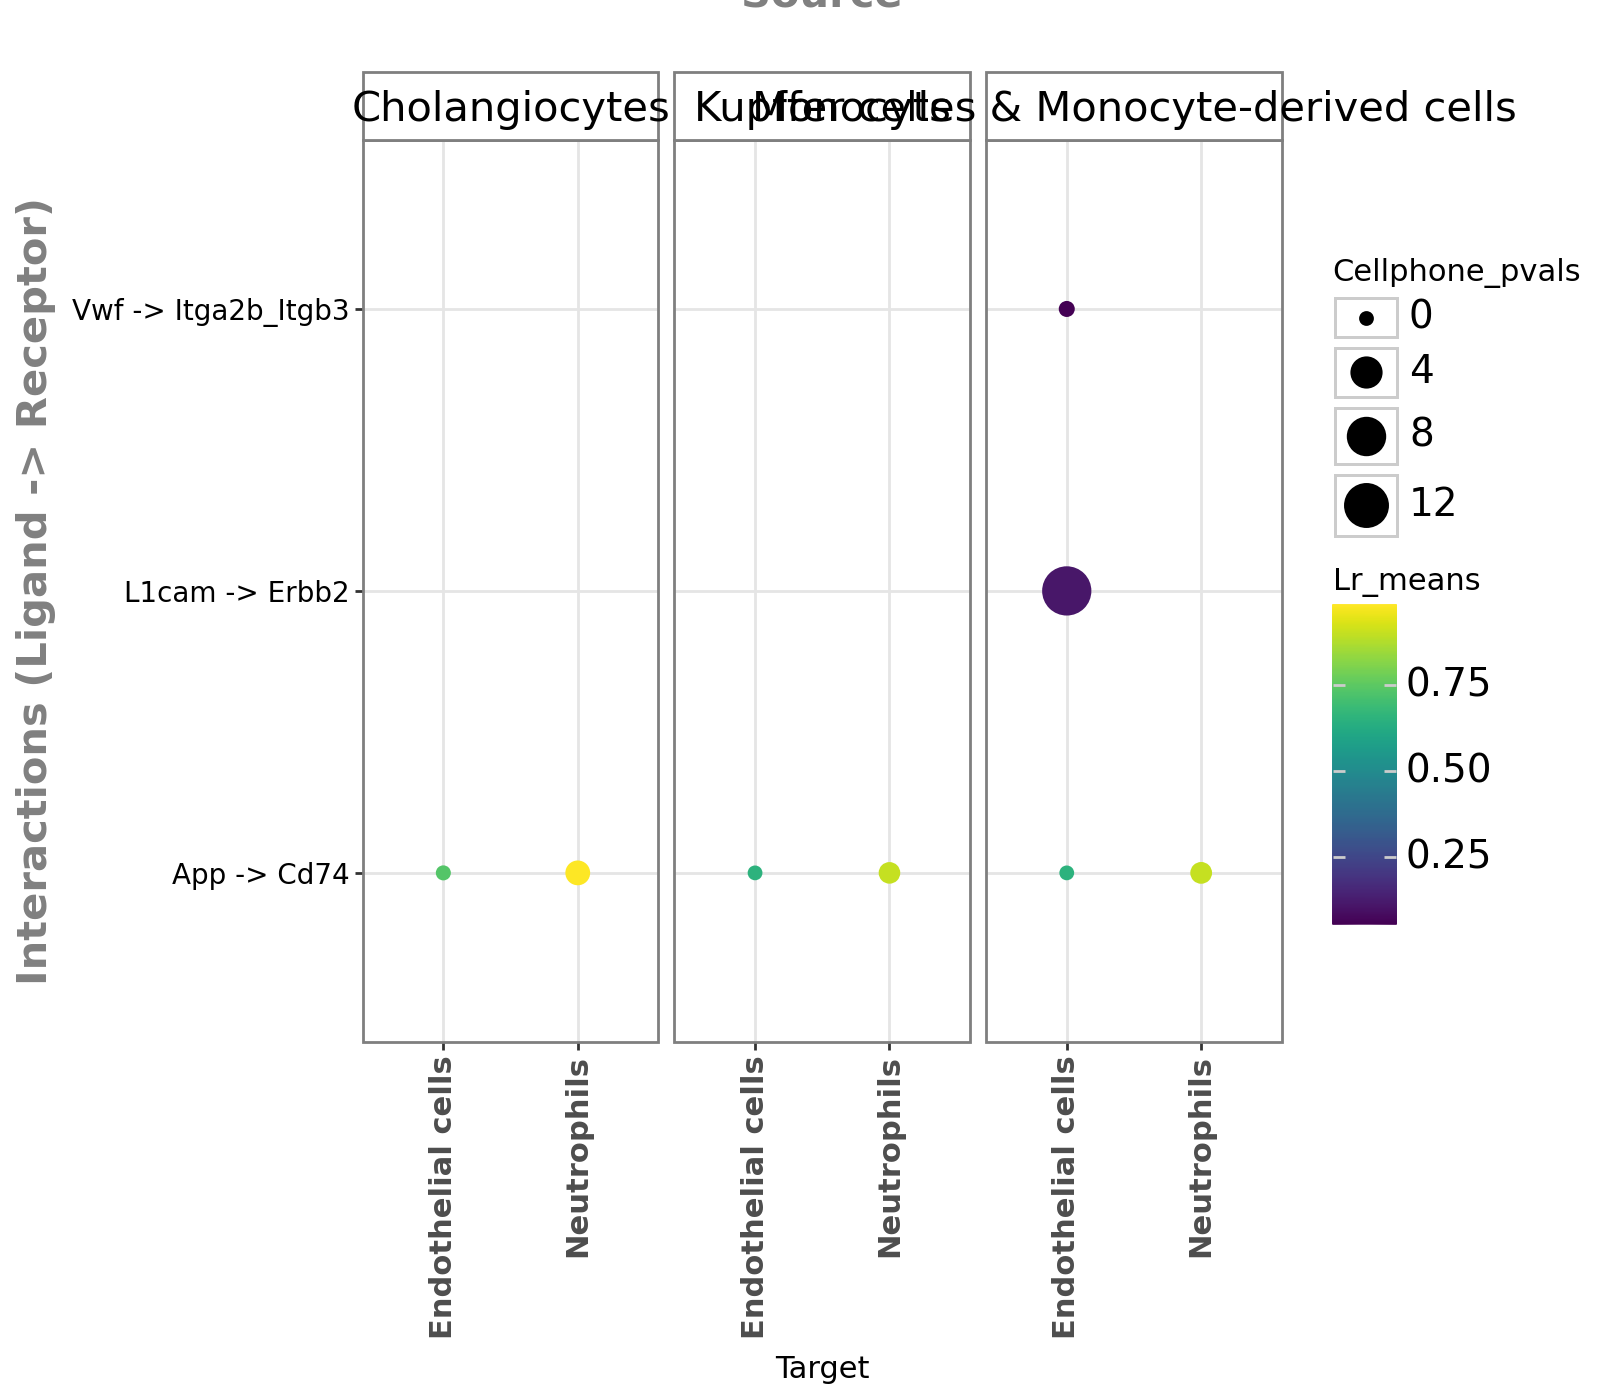

In [11]:
li.pl.dotplot(adata = mouse_data,
              colour='lr_means',
              size='cellphone_pvals',
              inverse_size=True, # we inverse sign since we want small p-values to have large sizes
              source_labels=['Kupffer cells', 'Cholangiocytes', 'Monocytes & Monocyte-derived cells'],
              target_labels=['Neutrophils', 'Endothelial cells'],
              figure_size=(8, 7),
              ligand_complex=['App', 'Spp1', 'L1cam', 'Vwf'],
              receptor_complex=['Cd74', 'Erbb2', 'Itga2b_Itgb3'],
              
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              # filter_fun=lambda x: x['cellphone_pvals'] <= 0.05,
              uns_key='cpdb_res' # uns_key to use, default is 'liana_res'
             )
plt.savefig('dotplot.png', dpi=300)  # Save the plot to a file
plt.close()

In [12]:
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...


In [13]:
print(li.__version__)

0.1.9


In [14]:
print(dir(li.pl))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_dotplot', 'dotplot', 'dotplot_by_sample']


In [1]:
circle_plot_test = li.pl.circle_plot(adata = mouse_data,
                  uns_key='cpdb_res',
                  groupby='predicted_labels',
                  score_key='lr_means',
                  inverse_score=True,
                  source_labels='Neutrophils',
                  figure_size=(10, 10)
                  )
fig = circle_plot_test.get_figure()

# Save the Figure to a file
fig.savefig('circle_plot_test.png', dpi=300)  # Save the plot to a file
plt.close(fig)

NameError: name 'li' is not defined

In [ ]:
data_pt = li.pl.circle_plot(adata = mouse_data,
                  uns_key='cpdb_res'
                  groupby='predicted_labels',
                  score_key='lr_means',
                  inverse_score=True,
                  source_labels='Neutrophils',
                  figure_size=(10, 10)
                  )

In [ ]:
li.pl.circle_plot(mouse_data,
                  groupby='predicted_labels',
                  score_key='lr_means',
                  inverse_score=True,
                  source_labels='Neutrophils',
                  pivot_mode='counts',
                  figure_size=(10, 10),
                  )

In [44]:
li.pl.circle_plot(adata = mouse_data,
                  groupby='predicted_labels',
                  score_key='lr_means',
                  inverse_score=True,
                  source_labels='Neutrophils',
                  # filter_fun=lambda x: x['specificity_rank'] <= 0.05,
                  pivot_mode='counts', # NOTE: this will simply count the interactions, 'mean' is also available
                  figure_size=(10, 10),
                  )

AttributeError: module 'liana.plotting' has no attribute 'circle_plot'

In [28]:
x = mouse_data.uns['cpdb_res'][mouse_data.uns['cpdb_res']['cellphone_pvals'] < 0.05]
x

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
98512,App,App,1.250792,1.000000,Cd74,Cd74,1.869475,1.000000,Neutrophils,cDC1s,1.560133,0.000
95297,App,App,1.227161,1.000000,Cd74,Cd74,1.869475,1.000000,Endothelial cells,cDC1s,1.548318,0.000
105309,App,App,1.250792,1.000000,Cd74,Cd74,1.836114,1.000000,Neutrophils,cDC2s,1.543453,0.000
101717,App,App,1.227161,1.000000,Cd74,Cd74,1.836114,1.000000,Endothelial cells,cDC2s,1.531638,0.000
79205,Spp1,Spp1,1.725233,1.000000,Cd44,Cd44,1.315134,1.000000,Cholangiocytes,Neutrophils,1.520183,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
26508,Vtn,Vtn,0.059089,0.124324,Itga2b,Itga2b_Itgb3,0.049581,0.103920,Kupffer cells,Endothelial cells,0.054335,0.000
38082,Ltf,Ltf,0.060600,0.133333,Lrp11,Lrp11,0.047761,0.111111,Neutrophils,Fibroblasts,0.054181,0.002
26693,Fgb,Fgb,0.056330,0.118919,Itga2b,Itga2b,0.049581,0.103920,Kupffer cells,Endothelial cells,0.052955,0.000
25138,Icam4,Icam4,0.051315,0.111111,Itga2b,Itga2b,0.049581,0.103920,Fibroblasts,Endothelial cells,0.050448,0.000


In [36]:
sorted_pvals = x['cellphone_pvals'].sort_values(axis=0)

In [37]:
sorted_pvals

98512     0.000
105921    0.000
17089     0.000
40803     0.000
66366     0.000
          ...  
61277     0.049
59215     0.049
87523     0.049
56913     0.049
77820     0.049
Name: cellphone_pvals, Length: 39459, dtype: float64

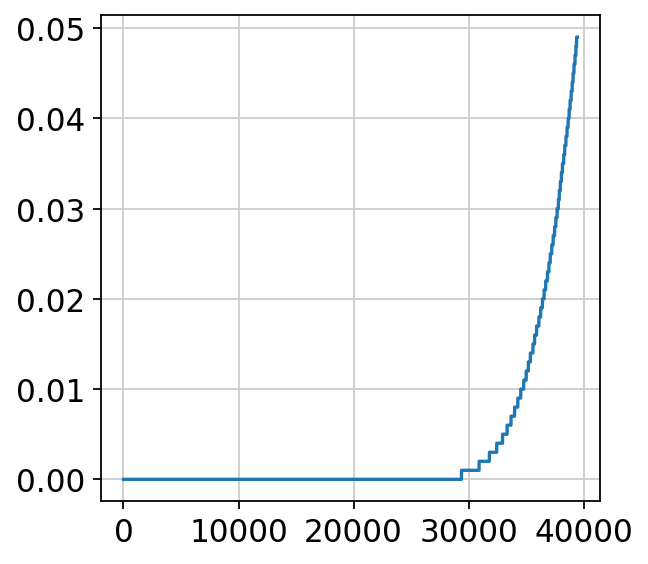

In [38]:
plt.plot(range(0,len(sorted_pvals)),sorted_pvals)
plt.show()

In [14]:
# run cellphonedb
cellphonedb(bdata,
            groupby='predicted_labels',
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='mouseconsensus',
            expr_prop=0.1,
            verbose=True, key_added='cpdb_res')

Using `.raw`!


/s/medinfo/bmi776/miniconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


Converting mat to CSR format


/home/gupta385/.local/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


0.11 of entities in the resource are missing from the data.
Generating ligand-receptor stats for 92942 samples and 23249 features


100%|██████████████████████████████████████████████████████████████████████████████████| 1000/1000 [04:18<00:00,  3.87it/s]


In [15]:
adata.uns['cpdb_res'].head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
65258,Apoe,Apoe,1.818773,0.997883,Sorl1,Sorl1,1.395129,0.985552,Kupffer cells,Neutrophils,1.606951,0.0
64671,Apoe,Apoe,1.791760,0.999480,Sorl1,Sorl1,1.395129,0.985552,Hepatocytes,Neutrophils,1.593444,0.0
63128,Spp1,Spp1,1.655790,1.000000,Cd44,Cd44,1.506064,0.989492,Cholangiocytes,Neutrophils,1.580927,0.0
22074,S100a9,S100a9,1.918484,0.971103,Cd36,Cd36,1.133381,0.966416,Neutrophils,Endothelial cells,1.525933,0.0
22070,S100a8,S100a8,1.913112,0.975044,Cd36,Cd36,1.133381,0.966416,Neutrophils,Endothelial cells,1.523247,0.0


In [29]:
adata

AnnData object with n_obs × n_vars = 92942 × 23249
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'percent.mt', 'percent.hbb', 'percent.hba', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'n_genes'
    var: 'total_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'n_cells'
    uns: 'neighbors', 'over_clustering', 'predicted_labels_colors', 'umap', 'log1p', 'cpdb_res'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [1]:
store_data = sc.datasets.pbmc68k_reduced()

NameError: name 'sc' is not defined

In [30]:
li.pl.dotplot(adata = adata,
              colour='lr_means',
              size='cellphone_pvals',
              inverse_size=True, # we inverse sign since we want small p-values to have large sizes
              source_labels=['Kupffer cells', 'Hepatocytes', 'Cholangiocytes'],
              target_labels=['Neutrophils', 'Endothelial cells'],
              figure_size=(8, 7),
              top_n = 5,
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              # filter_fun=lambda x: x['cellphone_pvals'] <= 0.05,
              uns_key='cpdb_res' # uns_key to use, default is 'liana_res'
             )

KeyError: 'Column(s) [None] do not exist'

In [31]:
my_plot = li.pl.tileplot(adata = adata,
                         # NOTE: fill & label need to exist for both
                         # ligand_ and receptor_ columns
                         fill='means',
                         label='props',
                         label_fun=lambda x: f'{x:.2f}',
                         top_n=10,
                         orderby='cellphone_pvals',
                         orderby_ascending=True,
                         source_labels=['Kupffer cells', 'Hepatocytes', 'Cholangiocytes'],
                         target_labels=['Neutrophils', 'Endothelial cells'],
                         uns_key='cpdb_res', # NOTE: default is 'liana_res'
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(8, 7)
                         )
my_plot

AttributeError: module 'liana.plotting' has no attribute 'tileplot'